<a href="https://colab.research.google.com/github/Aravindr017/CNN_ModelBuilding_CIFAR-100_dataset/blob/main/Model/ComputerVision_cifar_100(dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
!pip install tensorflow
!pip install opencv-python

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle


from sklearn.model_selection import train_test_split


# Reading Data

In [3]:

dataset_path = "/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/cifar-100"

print(os.listdir(dataset_path))

['meta', 'file.txt', 'test', 'train']


In [4]:
IMG_SIZE = 32          # Custom CNN input size (native CIFAR-100 resolution -> fastest, no upscaling)
VGG_IMG_SIZE = 32      # VGG16 input size. NOTE: VGG16 was designed for 224x224 images and has 5
                       # pooling stages, so at 32x32 its feature map collapses to 1x1 before the
                       # classifier head -> expect limited accuracy from VGG16 at this size no matter
                       # what. Raise this (e.g. 96) if you want VGG16 to have a fair chance.
BATCH_SIZE = 128
IMAGES_PER_CLASS = 300  # was 100 -> too little signal for 100 classes. Max available is 600/class
                        # (500 train + 100 test combined). Raise toward 600 if training time allows.

# ==========================
# Dataset Path
# ==========================
dataset_path = "/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/cifar-100"

# ==========================
# Function to Load CIFAR-100 File
# ==========================
def load_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")

    images = data[b"data"]
    labels = data[b"fine_labels"]

    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return images, np.array(labels).reshape(-1, 1)

def load_meta_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    return [label.decode('utf-8') for label in data[b'fine_label_names']]

# ==========================
# Load Train & Test Sets
# ==========================
x_train, y_train = load_file(dataset_path + "/train")
x_test, y_test = load_file(dataset_path + "/test")

# Load class names
class_names = load_meta_file(dataset_path + "/meta")

# Combine datasets
X = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# ==========================
# Balanced Sampling
# ==========================
np.random.seed(42)

X_balanced = []
y_balanced = []

for cls in np.unique(y):

    cls_idx = np.where(y.flatten() == cls)[0]

    selected_idx = np.random.choice(
        cls_idx,
        IMAGES_PER_CLASS,
        replace=False
    )

    X_balanced.append(X[selected_idx])
    y_balanced.append(y[selected_idx])

X = np.concatenate(X_balanced)
y = np.concatenate(y_balanced)

# Shuffle
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

# ==========================
# Train-Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# Data Augmentation Layers (Custom CNN pipeline: geometric + contrast)
# ==========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

# Geometric-only augmentation for the VGG pipeline (contrast + preprocess_input's mean-centering
# don't mix well, so we keep VGG's color statistics untouched by RandomContrast)
vgg_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ==========================
# Preprocessing - Custom CNN ([0,1] normalized RGB)
# ==========================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.clip_by_value(data_augmentation(x, training=True), 0.0, 1.0), y),
         num_parallel_calls=tf.data.AUTOTUNE)  # augment + clip back to [0,1]
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ==========================
# Preprocessing - VGG16 (must match what the pretrained weights expect: BGR + ImageNet mean-centering)
# ==========================
def preprocess_vgg(image, label):
    image = tf.image.resize(image, (VGG_IMG_SIZE, VGG_IMG_SIZE))
    image = tf.cast(image, tf.float32)  # keep 0-255 range, preprocess_input handles the rest
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label

vgg_train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (vgg_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (tf.keras.applications.vgg16.preprocess_input(
            tf.image.resize(img, (VGG_IMG_SIZE, VGG_IMG_SIZE))), lbl),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

vgg_test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess_vgg, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Number of classes: 100
Train samples: 24000, Test samples: 6000


# Model Building - Custom CNN

In [5]:
# Custom CNN Model - Tensorflow

model = tf.keras.Sequential([

    # Layer 1
    tf.keras.layers.Conv2D(
        16,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    # Layer 2
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.30),

    # Layer 3
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.35),

    # Fully Connected Layer
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu',
        kernel_initializer='he_normal'
    ),

    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
import time

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# Timing captured here directly, so we don't need to retrain the model again later just to time it
start_cnn = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=40,
    callbacks=[early_stop, checkpoint]
)

end_cnn = time.time()
cnn_time = end_cnn - start_cnn
print(f"Custom CNN Training Time : {cnn_time:.2f} seconds")

Epoch 1/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 60s 256ms/step - accuracy: 0.0128 - loss: 4.8264 - val_accuracy: 0.0205 - val_loss: 4.7479
Epoch 2/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.0215 - loss: 4.6515 - val_accuracy: 0.0352 - val_loss: 4.5229
Epoch 3/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 151ms/step - accuracy: 0.0280 - loss: 4.4971 - val_accuracy: 0.0418 - val_loss: 4.4260
Epoch 4/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 153ms/step - accuracy: 0.0280 - loss: 4.4271 - val_accuracy: 0.0445 - val_loss: 4.3194
Epoch 5/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 153ms/step - accuracy: 0.0317 - loss: 4.3726 - val_accuracy: 0.0557 - val_loss: 4.2608
Epoch 6/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.0371 - loss: 4.3112 - val_accuracy: 0.0628 - val_loss: 4.1597
Epoch 7/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 154ms/step - accuracy: 0.0440 - loss: 4.2538 - val_accuracy: 0.0563 - val_loss: 4.2724
Epoch 8/40
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.0439 - loss: 4

In [7]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1492 - loss: 3.6237
Test Loss     : 3.6237
Test Accuracy : 14.92%


## Plots - Training and Validation

- Loss and accuracy plots

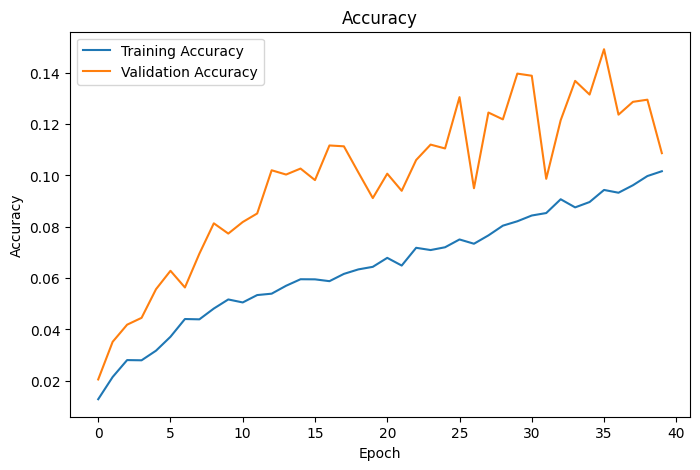

In [8]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

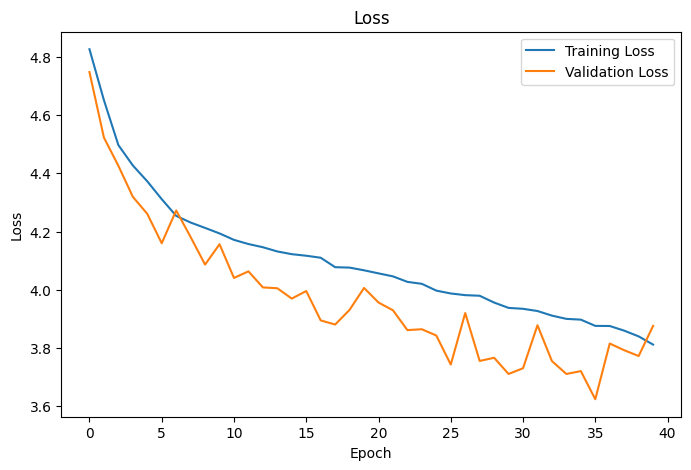

In [9]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Model Summary

In [10]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,950 (1.92 MB)

 Trainable params: 167,908 (655.89 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 335,818 (1.28 MB)

# Predefined Architecture(VGG-16)

In [11]:
# Load the model

base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(VGG_IMG_SIZE, VGG_IMG_SIZE, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [12]:
# Freeze pretrained convolutional layers
base_model.trainable = False

# the weights will not change during training.

In [13]:
# Building the model

vgg_model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),  # more robust than Flatten when spatial dims are tiny (e.g. 1x1 at 32px input)

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [14]:
# compile the model

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop_vgg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_vgg = tf.keras.callbacks.ModelCheckpoint(
    'best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [17]:
# train the model
print("Training Started...")

start_vgg = time.time()

history_vgg = vgg_model.fit(
    vgg_train_dataset,
    validation_data=vgg_test_dataset,
    epochs=10,
    callbacks=[early_stop_vgg, checkpoint_vgg]
)

end_vgg = time.time()
vgg_time = end_vgg - start_vgg
print(f"VGG16 Training Time : {vgg_time:.2f} seconds")

Training Started...
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 187ms/step - accuracy: 0.0988 - loss: 4.0848 - val_accuracy: 0.1660 - val_loss: 3.6949
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - accuracy: 0.1084 - loss: 3.9869 - val_accuracy: 0.1765 - val_loss: 3.5758
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 174ms/step - accuracy: 0.1175 - loss: 3.8940 - val_accuracy: 0.1973 - val_loss: 3.4688
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 176ms/step - accuracy: 0.1286 - loss: 3.8113 - val_accuracy: 0.2050 - val_loss: 3.3787
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 183ms/step - accuracy: 0.1380 - loss: 3.7324 - val_accuracy: 0.2127 - val_loss: 3.3164
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 174ms/step - accuracy: 0.1468 - loss: 3.6685 - val_accuracy: 0.2385 - val_loss: 3.2183
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - accuracy: 0.1561 - loss: 3.5973 - val_accuracy: 0.2375 - val_loss: 3.1452
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 33s 174ms/step - accura

In [18]:
# evaluate the model

test_loss, test_accuracy = vgg_model.evaluate(vgg_test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2568 - loss: 2.9879
Test Loss     : 2.9879
Test Accuracy : 25.68%


In [19]:
# save the model

vgg_model.save("vgg16_cifar100.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Model summary

In [20]:
vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,950,382 (57.03 MB)

 Trainable params: 78,564 (306.89 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 157,130 (613.79 KB)

# Making Predictions using the model

## Predictions Using Custom CNN

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 


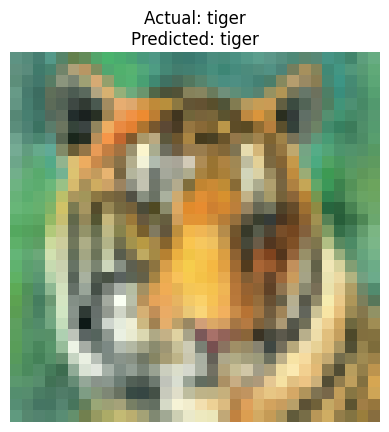

Actual Label    : tiger
Predicted Label : tiger
Confidence      : 4.40%


In [21]:
# Get one batch from the test dataset
images, labels = next(iter(test_dataset))

# Predict using the custom CNN
predictions = model.predict(images)

# Select an image
index = 0

# Get predicted and actual labels
predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display the image
plt.imshow(images[index])
plt.axis('off')
plt.title(f"Actual: {class_names[true_class]}\nPredicted: {class_names[predicted_class]}")
plt.show()

print(f"Actual Label    : {class_names[true_class]}")
print(f"Predicted Label : {class_names[predicted_class]}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

## Predictions using VGG-16

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


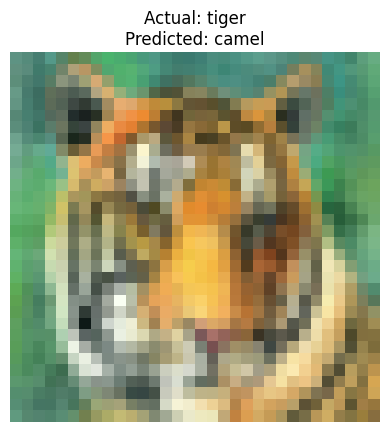

Actual Label    : tiger
Predicted Label : camel
Confidence      : 15.37%


In [22]:
# Get one batch from each dataset (same underlying images/order comes from the same X_test/y_test,
# but we display the human-viewable [0,1] version and predict on the VGG-preprocessed version)
images_display, labels = next(iter(test_dataset))
images_vgg, _ = next(iter(vgg_test_dataset))

# Predict
predictions = vgg_model.predict(images_vgg)

# Select an image
index = 0

predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display image (using the displayable [0,1] version, not the mean-centered VGG input)
plt.imshow(images_display[index])
plt.axis("off")
plt.title(f"Actual: {class_names[true_class]}\nPredicted: {class_names[predicted_class]}")
plt.show()

print(f"Actual Label    : {class_names[true_class]}")
print(f"Predicted Label : {class_names[predicted_class]}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

# Evaluating The model

## Custom CNN

In [23]:
# Evaluate Custom CNN

cnn_loss, cnn_accuracy = model.evaluate(test_dataset)

print("----- Custom CNN -----")
print(f"Test Loss     : {cnn_loss:.4f}")
print(f"Test Accuracy : {cnn_accuracy*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1492 - loss: 3.6237
----- Custom CNN -----
Test Loss     : 3.6237
Test Accuracy : 14.92%


## VGG-16

In [24]:
# Evaluate VGG-16

vgg_loss, vgg_accuracy = vgg_model.evaluate(vgg_test_dataset)

print("----- VGG16 -----")
print(f"Test Loss     : {vgg_loss:.4f}")
print(f"Test Accuracy : {vgg_accuracy*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2568 - loss: 2.9879
----- VGG16 -----
Test Loss     : 2.9879
Test Accuracy : 25.68%


## Comparing two models

In [25]:
print("\nModel Comparison")
print("-"*45)

print(f"{'Model':<15}{'Loss':<12}{'Accuracy'}")
print("-"*45)

print(f"{'Custom CNN':<15}{cnn_loss:<12.4f}{cnn_accuracy*100:.2f}%")
print(f"{'VGG16':<15}{vgg_loss:<12.4f}{vgg_accuracy*100:.2f}%")


Model Comparison
---------------------------------------------
Model          Loss        Accuracy
---------------------------------------------
Custom CNN     3.6237      14.92%
VGG16          2.9879      25.68%


In [26]:
# compare no of parameters
print("Custom CNN Parameters :", model.count_params())
print("VGG16 Parameters      :", vgg_model.count_params())

Custom CNN Parameters : 168132
VGG16 Parameters      : 14793252


In [27]:
# compare training time (captured live during each model's actual training run above -
# no need to retrain either model again just to measure this)
print(f"Custom CNN Training Time : {cnn_time:.2f} seconds")
print(f"VGG16 Training Time      : {vgg_time:.2f} seconds")

Custom CNN Training Time : 1321.72 seconds
VGG16 Training Time      : 334.09 seconds
